# Importing libraries

In [6]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import copy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from geexhp import datagen, datamod, datavis
from geexhp import stages as st_

datavis.configure_matplotlib(oldschool=False)

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test 1 - Loading HWO configuration file for Modern Earth

In [8]:
dg = datagen.DataGen()
config_str = dg.config_str
config_dict = dg._parse_config(config_str)

In [9]:
molecules = config_dict["ATMOSPHERE-LAYERS-MOLECULES"].split(",")
pressures = []
temperatures = []
concentration_dict = {mol: [] for mol in molecules}

for i in range(60):
    layer = config_dict.get(f"ATMOSPHERE-LAYER-{i + 1}").split(",")
    pressure = float(layer[0])
    temperature = float(layer[1])
    concentrations = [float(value) for value in layer[2:]]

    pressures.append(pressure)
    temperatures.append(temperature)
    for j, mol in enumerate(molecules):
        concentration_dict[mol].append(concentrations[j])

data = {"Pressure": pressures, "Temperature": temperatures}
data.update(concentration_dict)
mixing_ratio = pd.DataFrame(data)

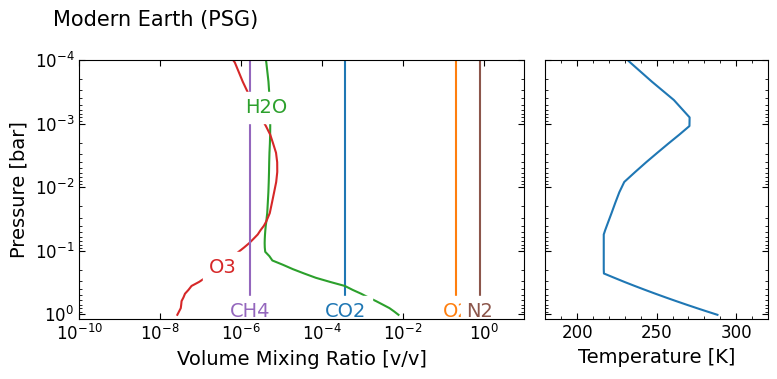

In [10]:
molecules = ["CO2", "O2", "H2O", "O3", "CH4", "N2"]

fig, ax = plt.subplots(
    ncols=2,
    nrows=1,
    figsize=(8, 4),
    gridspec_kw={"width_ratios": [3, 1.5]},
    sharey=True,
)
for molecule in molecules:
    (line,) = ax[0].plot(
        mixing_ratio[molecule], mixing_ratio["Pressure"], label=molecule
    )
    x_pos = np.median(line.get_xdata())
    datavis.label_line(line, x=x_pos, label=molecule, align=False)

ax[0].invert_yaxis()
ax[0].axis([1e-10, 10, 1.2, 1e-4])
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set(xlabel="Volume Mixing Ratio [v/v]", ylabel="Pressure [bar]")

mixing_ratio.plot(x="Temperature", y="Pressure", ax=ax[1], legend=False)
ax[1].invert_yaxis()
ax[1].axis([180, 320, 1.2, 1e-4])
ax[1].set(xlabel="Temperature [K]", ylabel="")
ax[1].set_yscale("log")

fig.suptitle(
    "Modern Earth (PSG)",
    x=0.08,
    y=0.95,
    horizontalalignment="left",
    verticalalignment="top",
    fontsize=15,
)
plt.tight_layout()
plt.show()

In [11]:
def test_instrument(config, instrument):
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})

In [12]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
dfs = [test_instrument(config_str, instrument) for instrument in instruments]
habex = pd.concat(dfs).reset_index(drop=True)

In [13]:
test_instrument(config_str, "SS-UV").shape, test_instrument(
    config_str, "SS-Vis"
).shape, test_instrument(config_str, "SS-NIR").shape

((7, 2), (109, 2), (25, 2))

In [14]:
test_instrument(config_str, "SS-NIR")["WAVELENGTH"].to_numpy()

array([0.975     , 0.999375  , 1.02435937, 1.04996836, 1.07621757,
       1.10312301, 1.13070108, 1.15896861, 1.18794282, 1.2176414 ,
       1.24808243, 1.27928449, 1.3112666 , 1.34404827, 1.37764947,
       1.41209071, 1.44739298, 1.4835778 , 1.52066725, 1.55868393,
       1.59765103, 1.63759231, 1.67853211, 1.72049542, 1.7635078 ])

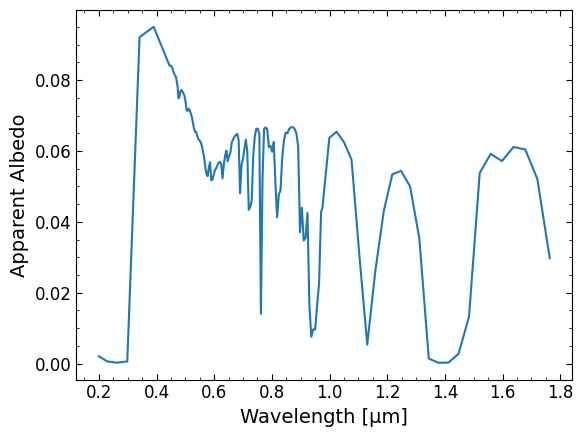

In [15]:
plt.plot(habex["WAVELENGTH"], habex["ALBEDO"])
plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.show()

In [16]:
instruments = ["B-UV", "B-Vis", "B-NIR"]
dfs = [test_instrument(config_str, instrument) for instrument in instruments]
luvoir = pd.concat(dfs).reset_index(drop=True)

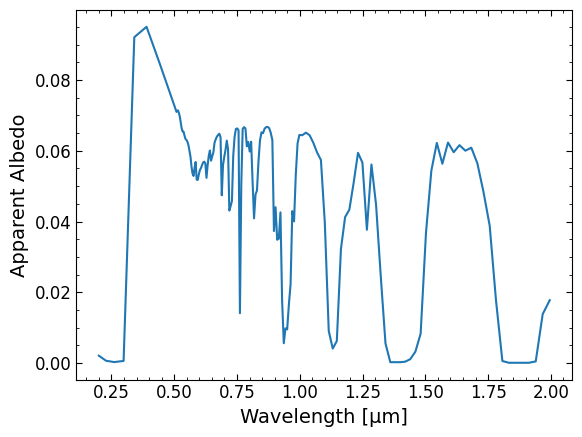

In [17]:
plt.plot(luvoir["WAVELENGTH"], luvoir["ALBEDO"])
plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.show()

Since the spectra are similar, we will only do it for HaBex here, but the code can be rewritten to simulate it for LUVOIR.

# Test 2 - Changing the abundances

In [18]:
def test_abundance(config, instrument, gas, multiplier):
    modified_config = config.copy()
    elements = ["CO2", "O2", "H2O", "CO", "O3", "CH4", "N2O", "N2"]
    gas_index = elements.index(gas)

    for key, value in modified_config.items():
        if key.startswith("ATMOSPHERE-LAYER-"):
            values = value.split(",")
            gas_value = float(values[gas_index + 2])
            new_value = gas_value * multiplier
            values[gas_index + 2] = str(new_value)
            modified_config[key] = ",".join(values)

    datamod.set_instrument(modified_config, instrument)
    config = dg._serialize_config(modified_config)
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})

In [19]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]

results_double_O2 = [
    test_abundance(config_dict, instrument, "O2", 2) for instrument in instruments
]
results_no_O2 = [
    test_abundance(config_dict, instrument, "O2", 0) for instrument in instruments
]

df_double_O2 = pd.concat(results_double_O2).reset_index(drop=True)
df_no_O2 = pd.concat(results_no_O2).reset_index(drop=True)

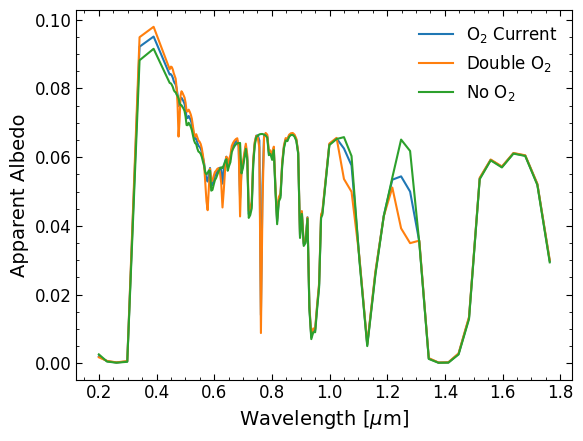

In [20]:
_, ax = plt.subplots()

ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="O${}_2$ Current")
ax.plot(df_double_O2["WAVELENGTH"], df_double_O2["ALBEDO"], label="Double O${}_2$")
ax.plot(df_no_O2["WAVELENGTH"], df_no_O2["ALBEDO"], label="No O${}_2$")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

In [21]:
results_double_H2O = [
    test_abundance(config_dict, instrument, "H2O", 2) for instrument in instruments
]
results_no_H2O = [
    test_abundance(config_dict, instrument, "H2O", 0) for instrument in instruments
]

df_double_H2O = pd.concat(results_double_H2O).reset_index(drop=True)
df_no_H2O = pd.concat(results_no_H2O).reset_index(drop=True)

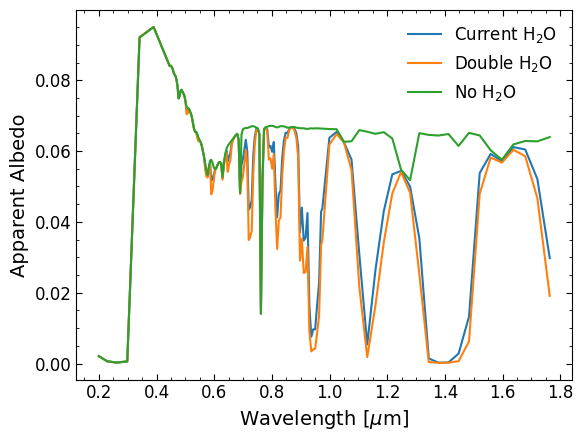

In [22]:
_, ax = plt.subplots()

ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Current H${}_2$O")
ax.plot(df_double_H2O["WAVELENGTH"], df_double_H2O["ALBEDO"], label="Double H${}_2$O")
ax.plot(df_no_H2O["WAVELENGTH"], df_no_H2O["ALBEDO"], label="No H${}_2$O")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

In [23]:
results_double_O3 = [
    test_abundance(config_dict, instrument, "O3", 2) for instrument in instruments
]
results_no_O3 = [
    test_abundance(config_dict, instrument, "O3", 0) for instrument in instruments
]

df_double_O3 = pd.concat(results_double_O3).reset_index(drop=True)
df_no_O3 = pd.concat(results_no_O3).reset_index(drop=True)

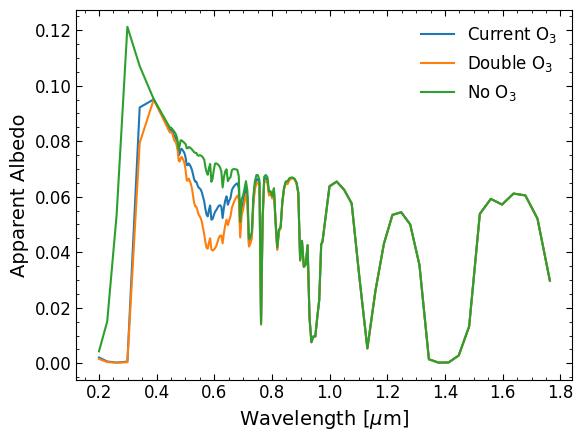

In [24]:
_, ax = plt.subplots()

ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Current O${}_3$")
ax.plot(df_double_O3["WAVELENGTH"], df_double_O3["ALBEDO"], label="Double O${}_3$")
ax.plot(df_no_O3["WAVELENGTH"], df_no_O3["ALBEDO"], label="No O${}_3$")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

In [25]:
results_double_N2O = [
    test_abundance(config_dict, instrument, "N2O", 1000) for instrument in instruments
]
results_no_N2O = [
    test_abundance(config_dict, instrument, "N2O", 0) for instrument in instruments
]

df_double_N2O = pd.concat(results_double_N2O).reset_index(drop=True)
df_no_N2O = pd.concat(results_no_N2O).reset_index(drop=True)

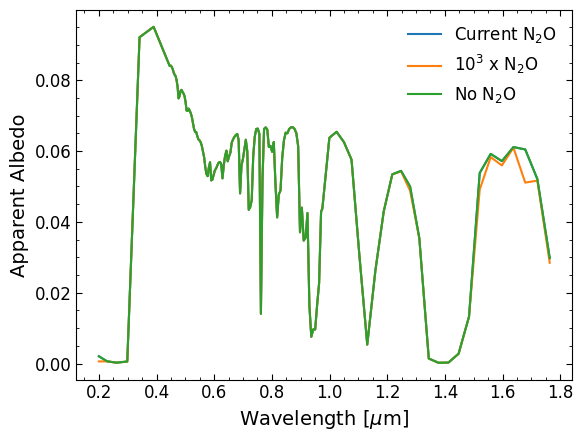

In [26]:
_, ax = plt.subplots()

ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Current N${}_2$O")
ax.plot(df_double_N2O["WAVELENGTH"], df_double_N2O["ALBEDO"], label="$10^3$ x N${}_2$O")
ax.plot(df_no_N2O["WAVELENGTH"], df_no_N2O["ALBEDO"], label="No N${}_2$O")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

In [27]:
results_double_N2O = [
    test_abundance(config_dict, instrument, "CO", 10000) for instrument in instruments
]
results_no_N2O = [
    test_abundance(config_dict, instrument, "CO", 0) for instrument in instruments
]

df_double_N2O = pd.concat(results_double_N2O).reset_index(drop=True)
df_no_N2O = pd.concat(results_no_N2O).reset_index(drop=True)

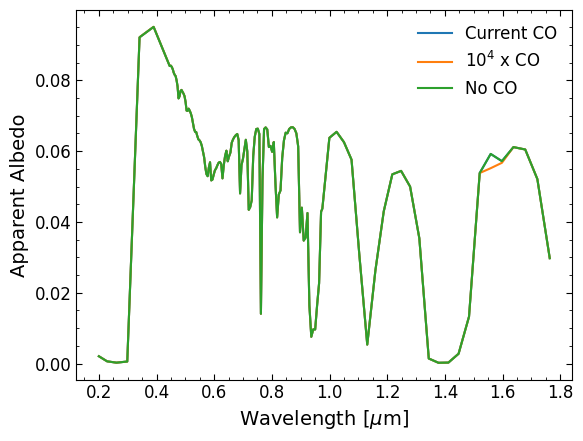

In [28]:
_, ax = plt.subplots()

ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Current CO")
ax.plot(df_double_N2O["WAVELENGTH"], df_double_N2O["ALBEDO"], label="$10^{4}$ x CO")
ax.plot(df_no_N2O["WAVELENGTH"], df_no_N2O["ALBEDO"], label="No CO")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

# Test 3 - Modifying atmospheric pressure (mbar)

In [29]:
def test_pressure(config, instrument, pressure):
    modified_config = config.copy()
    modified_config["ATMOSPHERE-PRESSURE"] = str(pressure)

    config = dg._serialize_config(modified_config)
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})

In [30]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
pressures = [500, 1000, 1500]

df_half_atm = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[0])
        for instrument in instruments
    ]
).reset_index(drop=True)

df_1_0_atm = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[1])
        for instrument in instruments
    ]
).reset_index(drop=True)

df_1_5_atm = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[2])
        for instrument in instruments
    ]
).reset_index(drop=True)

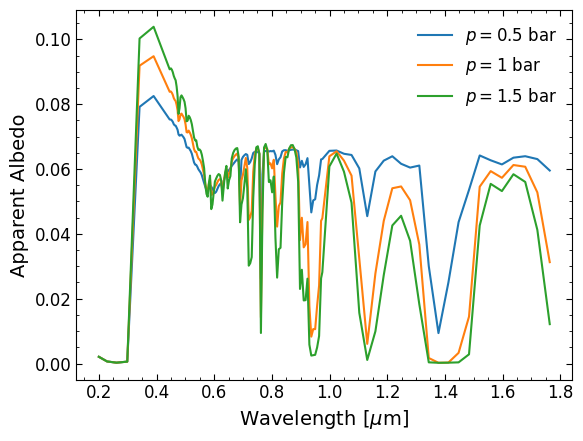

In [31]:
_, ax = plt.subplots()

ax.plot(df_half_atm["WAVELENGTH"], df_half_atm["ALBEDO"], label="$p = 0.5$ bar")
ax.plot(df_1_0_atm["WAVELENGTH"], df_1_0_atm["ALBEDO"], label="$p = 1$ bar")
ax.plot(df_1_5_atm["WAVELENGTH"], df_1_5_atm["ALBEDO"], label="$p = 1.5$ bar")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

When atmospheric pressure decreases, it generally indicates a more rarefied atmosphere. On the other hand, higher atmospheric pressure suggests a denser and more expansive atmosphere. The correlation between atmospheric density and the visibility of spectral signatures is intrinsically linked to photon-molecule interaction. In a dense atmosphere, the molecules present have more opportunities to interact with photons, resulting in more pronounced spectral signatures. However, when the atmosphere is more rarefied, these interactions decrease, leading to significant attenuation of spectral signatures.

# Test 4 - Modifying atmospheric temperature (K)

In [32]:
def test_temp(config, instrument, temperature):
    modified_config = config.copy()
    modified_config["ATMOSPHERE-TEMPERATURE"] = str(temperature)

    config = dg._serialize_config(modified_config)
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})

In [33]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
pressures = [273.15, 373.15, 673.15]

df_1_temp = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[0])
        for instrument in instruments
    ]
).reset_index(drop=True)

df_2_temp = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[1])
        for instrument in instruments
    ]
).reset_index(drop=True)

df_3_temp = pd.concat(
    [
        test_pressure(config_dict.copy(), instrument, pressures[2])
        for instrument in instruments
    ]
).reset_index(drop=True)

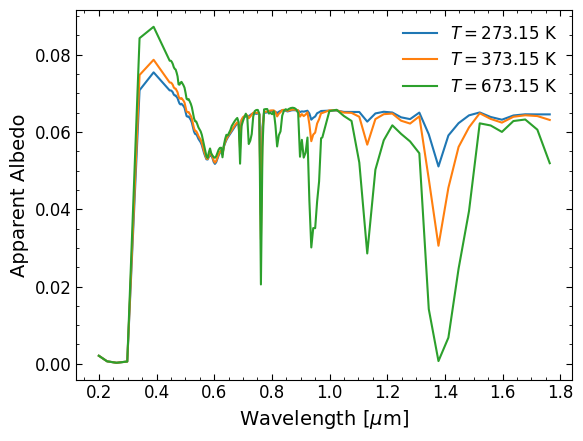

In [34]:
_, ax = plt.subplots()

ax.plot(df_1_temp["WAVELENGTH"], df_1_temp["ALBEDO"], label="$T = 273.15$ K")
ax.plot(df_2_temp["WAVELENGTH"], df_2_temp["ALBEDO"], label="$T = 373.15$ K")
ax.plot(df_3_temp["WAVELENGTH"], df_3_temp["ALBEDO"], label="$T = 673.15$ K")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

# Extra: How are other parameters influencing the spectrum?

In [35]:
def test_spectraltype(config, instrument, class_star):
    """
    Generate one spectrum for a controlled stellar-class test.

    For F, G, and K stars, temperature and radius follow the same joint
    main-sequence relation adopted in datamod. M dwarfs are retained for
    this internal experiment using an approximate main-sequence grid.

    The observer distance is fixed at 3 pc so that differences between
    experiments are not caused by distance.
    """
    class_star = class_star.upper()

    modified_config = config.copy()
    modified_config["OBJECT-STAR-TYPE"] = class_star

    # F, G and K use the same empirical main-sequence grid as datamod.
    if class_star in {"F", "G", "K"}:
        sequence = datamod._MAIN_SEQUENCE[class_star]
        temperature_grid = sequence["teff"]
        radius_grid = sequence["radius"]

    # M dwarfs are maintained only for this internal spectral experiment.
    else:
        temperature_grid = np.array(
            [
                2320.0,
                2570.0,
                2680.0,
                2810.0,
                3060.0,
                3210.0,
                3430.0,
                3560.0,
                3660.0,
                3870.0,
            ]
        )

        radius_grid = np.array(
            [
                0.104,
                0.112,
                0.121,
                0.137,
                0.196,
                0.274,
                0.361,
                0.446,
                0.501,
                0.559,
            ]
        )

    # Temperature is sampled first. Radius is then obtained conditionally
    # along the main-sequence relation rather than independently.
    star_temperature = np.random.uniform(
        temperature_grid[0],
        temperature_grid[-1],
    )

    star_radius = np.exp(
        np.interp(
            star_temperature,
            temperature_grid,
            np.log(radius_grid),
        )
    )

    modified_config["OBJECT-STAR-TEMPERATURE"] = star_temperature
    modified_config["OBJECT-STAR-RADIUS"] = star_radius

    # Fixed observer distance for a controlled comparison.
    modified_config["GEOMETRY-OBS-ALTITUDE"] = 3.0
    modified_config["GEOMETRY-ALTITUDE-UNIT"] = "pc"

    # These fields describe an occultation/background star in PSG,
    # not the parent star used in the direct-imaging calculation.
    modified_config.pop("GEOMETRY-STELLAR-TYPE", None)
    modified_config.pop("GEOMETRY-STELLAR-TEMPERATURE", None)
    modified_config.pop("GEOMETRY-STELLAR-MAGNITUDE", None)

    # Space-based observations must not apply terrestrial transmission.
    modified_config["GENERATOR-TRANS-APPLY"] = "N"

    config_str = dg._serialize_config(modified_config)

    wavelength, total, noise, noisy_albedo = dg._generate_spectrum_for_instrument(
        config_str,
        instrument,
    )

    return pd.DataFrame(
        {
            "WAVELENGTH": wavelength,
            "ALBEDO": total,
            "NOISE": noise,
            "NOISY_ALBEDO": noisy_albedo,
        }
    )

In [36]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
sts = ["F", "G", "K", "M"]

results_spectral_types = {
    st: [
        test_spectraltype(config_dict.copy(), instrument, st)
        for instrument in instruments
    ]
    for st in sts
}

F = pd.concat(results_spectral_types["F"]).reset_index(drop=True)
G = pd.concat(results_spectral_types["G"]).reset_index(drop=True)
K = pd.concat(results_spectral_types["K"]).reset_index(drop=True)
M = pd.concat(results_spectral_types["M"]).reset_index(drop=True)

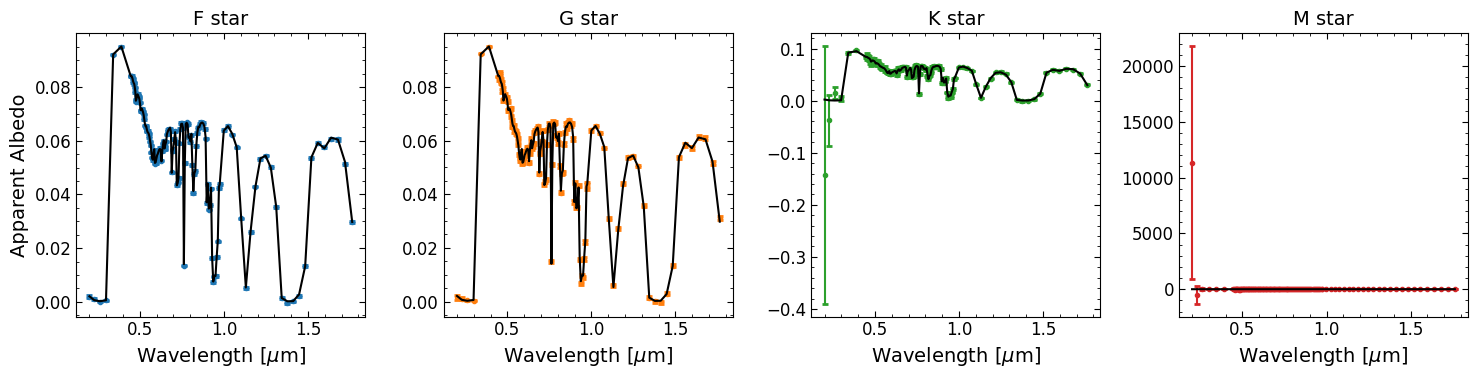

In [37]:
_, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4))

ax1.errorbar(
    F["WAVELENGTH"], F["NOISY_ALBEDO"], yerr=F["NOISE"], fmt=".", capsize=2, capthick=2
)
ax1.plot(F["WAVELENGTH"], F["ALBEDO"], color="k", zorder=3)
ax1.set_ylabel("Apparent Albedo")
ax1.set_title("F star")

ax2.errorbar(
    G["WAVELENGTH"],
    G["NOISY_ALBEDO"],
    yerr=G["NOISE"],
    fmt=".",
    capsize=2,
    capthick=2,
    color="tab:orange",
)
ax2.plot(G["WAVELENGTH"], G["ALBEDO"], color="k", zorder=3)
ax2.set_title("G star")

ax3.errorbar(
    K["WAVELENGTH"],
    K["NOISY_ALBEDO"],
    yerr=K["NOISE"],
    fmt=".",
    capsize=2,
    capthick=2,
    color="tab:green",
)
ax3.plot(K["WAVELENGTH"], K["ALBEDO"], color="k", zorder=3)
ax3.set_title("K star")

ax4.errorbar(
    M["WAVELENGTH"],
    M["NOISY_ALBEDO"],
    yerr=M["NOISE"],
    fmt=".",
    capsize=2,
    capthick=2,
    color="tab:red",
)
ax4.plot(M["WAVELENGTH"], M["ALBEDO"], color="k", zorder=3)
ax4.set_title("M star")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set(xlabel=r"Wavelength [$\mu$m]")

plt.tight_layout()
plt.show()

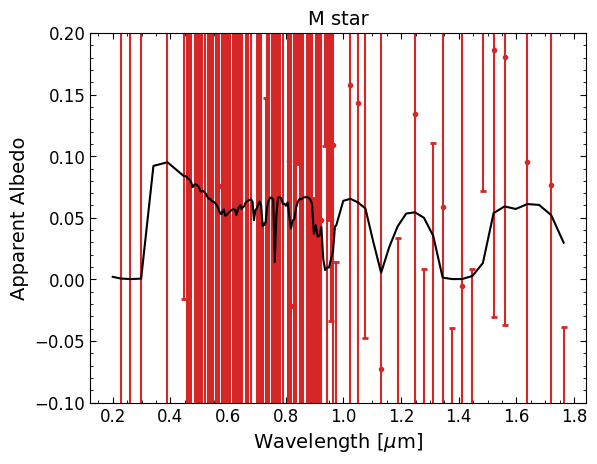

In [38]:
plt.errorbar(
    M["WAVELENGTH"],
    M["NOISY_ALBEDO"],
    yerr=M["NOISE"],
    fmt=".",
    capsize=2,
    capthick=2,
    color="tab:red",
)
plt.plot(M["WAVELENGTH"], M["ALBEDO"], color="k", zorder=3)
plt.ylim(-0.1, 0.2)
plt.title("M star")
plt.xlabel(r"Wavelength [$\mu$m]")
plt.ylabel("Apparent Albedo")
plt.show()

# 2.0Ga after the Great Oxidation Event (Proterozoic)

In [39]:
dg_proterozoic = datagen.DataGen(stage="proterozoic")
config_str_pro = dg_proterozoic.config_str
config_dict_pro = dg_proterozoic._parse_config(config_str_pro)

In [40]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
dfs = [test_instrument(config_str_pro, instrument) for instrument in instruments]
proterozoic = pd.concat(dfs).reset_index(drop=True)

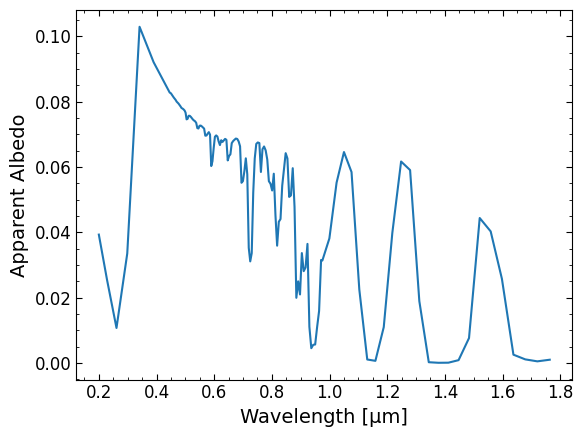

In [41]:
plt.plot(proterozoic["WAVELENGTH"], proterozoic["ALBEDO"])
plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.show()

## Archean Earth

In [42]:
dg_archean = datagen.DataGen(stage="archean")
config_str_arc = dg_archean.config_str
config_dict_arc = dg_archean._parse_config(config_str_arc)

In [43]:
instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
dfs = [test_instrument(config_str_arc, instrument) for instrument in instruments]
archean = pd.concat(dfs).reset_index(drop=True)

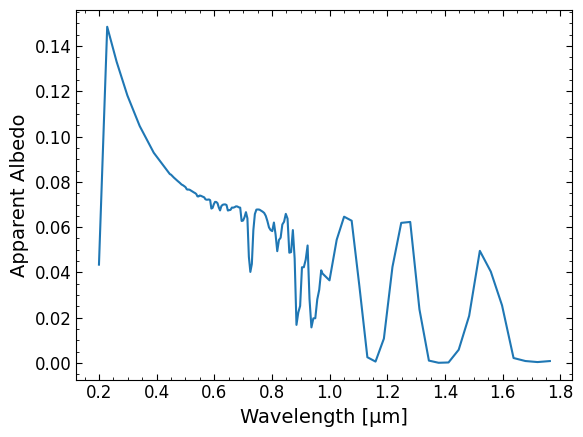

In [44]:
plt.plot(archean["WAVELENGTH"], archean["ALBEDO"])
plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.show()

In [45]:
def test_abundance_arc(config, instrument, gas, multiplier):
    modified_config = config.copy()
    elements = ["CH4", "H2O", "CO2", "N2"]
    gas_index = elements.index(gas)

    for key, value in modified_config.items():
        if key.startswith("ATMOSPHERE-LAYER-"):
            values = value.split(",")
            gas_value = float(values[gas_index + 2])
            new_value = gas_value * multiplier
            values[gas_index + 2] = str(new_value)
            modified_config[key] = ",".join(values)

    datamod.set_instrument(modified_config, instrument)
    config = dg._serialize_config(modified_config)
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})

In [46]:
results_double_CH4 = [
    test_abundance_arc(config_dict_arc, instrument, "CH4", 2)
    for instrument in instruments
]
results_no_CH4 = [
    test_abundance_arc(config_dict_arc, instrument, "CH4", 0)
    for instrument in instruments
]

df_double_CH4 = pd.concat(results_double_CH4).reset_index(drop=True)
df_no_CH4 = pd.concat(results_no_CH4).reset_index(drop=True)

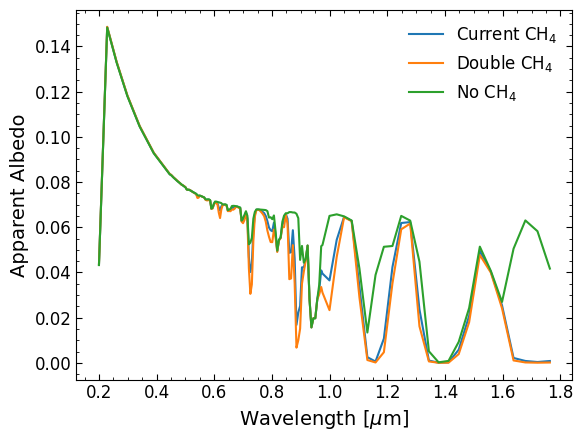

In [47]:
_, ax = plt.subplots()

ax.plot(archean["WAVELENGTH"], archean["ALBEDO"], label="Current CH$_4$")
ax.plot(
    df_double_CH4["WAVELENGTH"],
    df_double_CH4["ALBEDO"],
    label="Double CH$_4$",
)
ax.plot(df_no_CH4["WAVELENGTH"], df_no_CH4["ALBEDO"], label="No CH$_4$")
ax.set(xlabel=r"Wavelength [$\mu$m]", ylabel="Apparent Albedo")
ax.legend()
plt.show()

# All eons

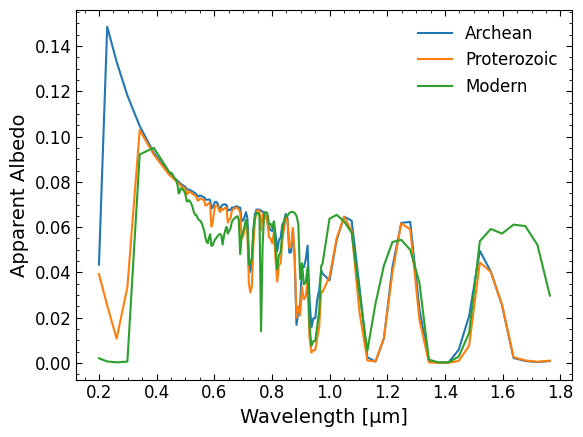

In [48]:
plt.plot(archean["WAVELENGTH"], archean["ALBEDO"], label="Archean")
plt.plot(proterozoic["WAVELENGTH"], proterozoic["ALBEDO"], label="Proterozoic")
plt.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Modern")
plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.legend()
plt.show()

## Generate a random modern earth

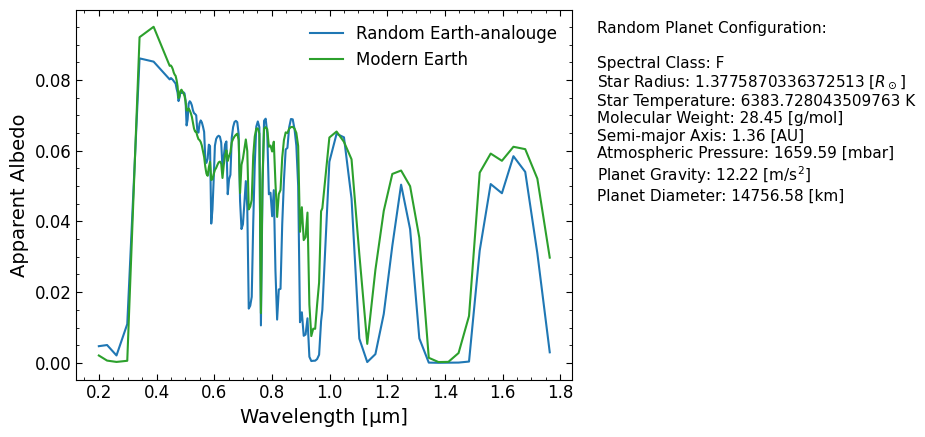

In [63]:
modified_config = config_dict.copy()
datamod.random_planet(modified_config, st_.molweightlist("modern"))


def test_random_planet(modified_config, instrument):
    config = dg._serialize_config(modified_config)
    wavelength, total, _, _ = dg._generate_spectrum_for_instrument(config, instrument)
    return pd.DataFrame({f"WAVELENGTH": wavelength, f"ALBEDO": total})


instruments = ["SS-UV", "SS-Vis", "SS-NIR"]
results = [
    test_random_planet(modified_config, instrument) for instrument in instruments
]
spectrum = pd.concat(results).reset_index(drop=True)

SPECTRAL_CLASS = modified_config["OBJECT-STAR-TYPE"]
STAR_RADIUS = modified_config["OBJECT-STAR-RADIUS"]
STAR_TEMPERATURE = modified_config["OBJECT-STAR-TEMPERATURE"]
MOLECULAR_WEIGHT = round(modified_config["ATMOSPHERE-WEIGHT"], 2)
SEMI_MAJOR_AXIS = round(modified_config["OBJECT-STAR-DISTANCE"], 2)
ATMOSPHERIC_PRESSURE = round(modified_config["ATMOSPHERE-PRESSURE"], 2)
PLANET_GRAVITY = round(modified_config["OBJECT-GRAVITY"], 2)
PLANET_DIAMETER = round(modified_config["OBJECT-DIAMETER"], 2)

_, ax = plt.subplots()
ax.plot(spectrum["WAVELENGTH"], spectrum["ALBEDO"], label="Random Earth-analouge")
ax.plot(habex["WAVELENGTH"], habex["ALBEDO"], label="Modern Earth", color="tab:green")
ax.legend()

text = (
    "Random Planet Configuration:\n\n"
    f"Spectral Class: {SPECTRAL_CLASS}\n"
    rf"Star Radius: {STAR_RADIUS} [$R_\odot$]" + "\n"
    f"Star Temperature: {STAR_TEMPERATURE} K\n"
    f"Molecular Weight: {MOLECULAR_WEIGHT} [g/mol]\n"
    f"Semi-major Axis: {SEMI_MAJOR_AXIS} [AU]\n"
    f"Atmospheric Pressure: {ATMOSPHERIC_PRESSURE} [mbar]\n"
    rf"Planet Gravity: {PLANET_GRAVITY} [m/s$^2$]" + "\n"
    f"Planet Diameter: {PLANET_DIAMETER} [km]\n"
)

plt.text(
    1.05,
    0.7,
    text,
    horizontalalignment="left",
    verticalalignment="center",
    fontsize=11,
    transform=plt.gca().transAxes,
)

plt.xlabel("Wavelength [μm]")
plt.ylabel("Apparent Albedo")
plt.show()

In [50]:
TELESCOPES = {
    "HabEx/SS": ["SS-UV", "SS-Vis", "SS-NIR"],
    "LUVOIR-B": ["B-UV", "B-Vis", "B-NIR"],
}
EPOCH_CONFIGS = {
    "modern": config_dict,
    "proterozoic": config_dict_pro,
    "archean": config_dict_arc,
}

EPOCH_SETTINGS = {
    "modern": {
        "title": "Modern",
        "color": "tab:blue",
    },
    "proterozoic": {
        "title": "Proterozoic",
        "color": "tab:green",
    },
    "archean": {
        "title": "Archean",
        "color": "tab:orange",
    },
}


def generate_spectrum(config, instruments):
    serialized_config = dg._serialize_config(config)
    channel_spectra = []

    for instrument in instruments:
        wavelength, total, _, _ = dg._generate_spectrum_for_instrument(
            serialized_config,
            instrument,
        )

        channel_spectra.append(
            pd.DataFrame(
                {
                    "WAVELENGTH": wavelength,
                    "ALBEDO": total,
                    "INSTRUMENT": instrument,
                }
            )
        )

    spectrum = pd.concat(channel_spectra, ignore_index=True)

    return spectrum.sort_values("WAVELENGTH").reset_index(drop=True)


def generate_spectra_for_both_telescopes(config):
    return {
        telescope: generate_spectrum(config=config, instruments=instruments)
        for telescope, instruments in TELESCOPES.items()
    }


def generate_random_population(
    base_config, era, n_examples=100, max_failed_attempts=500
):
    spectra = {telescope: [] for telescope in TELESCOPES}

    accepted_configs = []
    failed_attempts = 0

    molecular_weights = st_.molweightlist(era)

    while len(accepted_configs) < n_examples:
        random_config = copy.deepcopy(base_config)

        try:
            # random_planet modifies random_config in place
            datamod.random_planet(
                random_config,
                molecular_weights,
            )

            telescope_spectra = generate_spectra_for_both_telescopes(random_config)

            for telescope in TELESCOPES:
                spectra[telescope].append(telescope_spectra[telescope])

            accepted_configs.append(random_config)

            print(
                f"\r{era.capitalize()}: "
                f"{len(accepted_configs)}/{n_examples} "
                "planets generated",
                end="",
            )

        except (ValueError, RuntimeError) as error:
            failed_attempts += 1

            if failed_attempts >= max_failed_attempts:
                raise RuntimeError(
                    f"Could not generate {n_examples} valid {era} planets."
                ) from error

    print()

    return spectra, accepted_configs


template_spectra = {}

for era, base_config in EPOCH_CONFIGS.items():
    template_spectra[era] = generate_spectra_for_both_telescopes(
        copy.deepcopy(base_config)
    )

random_spectra = {}
random_configs = {}

for era, base_config in EPOCH_CONFIGS.items():
    spectra, configurations = generate_random_population(
        base_config=base_config, era=era, n_examples=100
    )

    random_spectra[era] = spectra
    random_configs[era] = configurations

Modern: 100/100 planets generated
Proterozoic: 100/100 planets generated
Archean: 100/100 planets generated


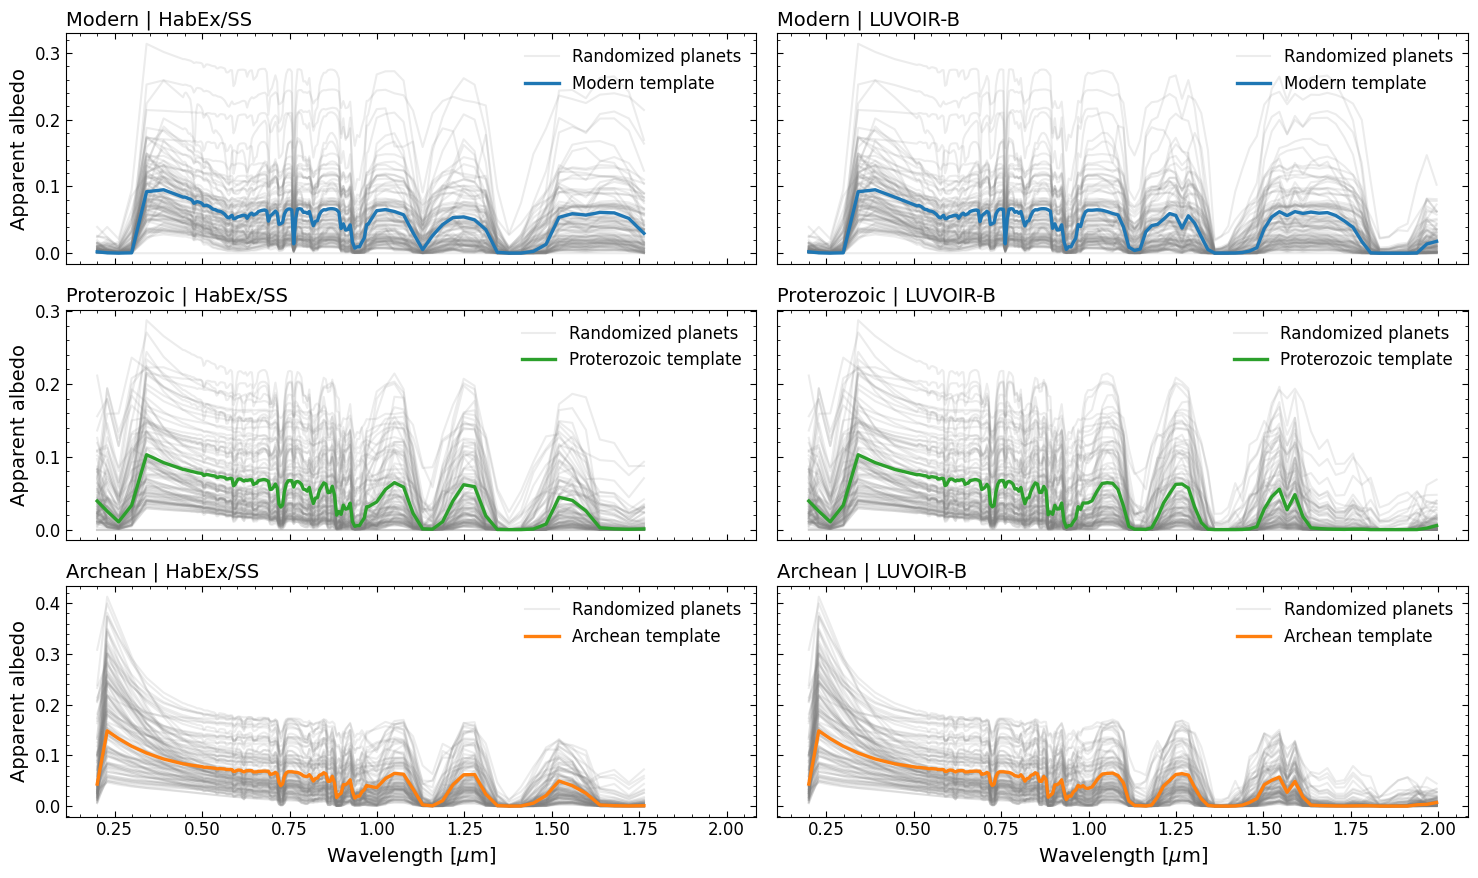

In [52]:
epoch_order = [
    "modern",
    "proterozoic",
    "archean",
]

telescope_order = ["HabEx/SS", "LUVOIR-B"]

_, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 9), sharey="row", sharex=True)

for row, era in enumerate(epoch_order):
    settings = EPOCH_SETTINGS[era]

    for column, telescope in enumerate(telescope_order):
        ax = axes[row, column]

        # randomized planets
        for index, spectrum in enumerate(random_spectra[era][telescope]):
            ax.plot(
                spectrum["WAVELENGTH"],
                spectrum["ALBEDO"],
                color="gray",
                alpha=0.15,
                label=("Randomized planets" if index == 0 else None),
            )
        # Unperturbed template
        template = template_spectra[era][telescope]

        ax.plot(
            template["WAVELENGTH"],
            template["ALBEDO"],
            color=settings["color"],
            linewidth=2.4,
            zorder=10,
            label=f"{settings['title']} template",
        )

        ax.set_title(f"{settings['title']} | {telescope}", loc="left")
        ax.legend()

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wavelength [$\mu$m]")

for ax in axes[:, 0]:
    ax.set_ylabel(r"Apparent albedo")

plt.tight_layout()
plt.show()